# Задача 3. Решение прямой задачи (forward task) для уравнения диффузии

Условие (`PINN2026-1/tasks/3_forward_task_diffusion/ex4.pdf`), по заготовке
`PINN2026-1/tasks/3_forward_task_diffusion/Forward_task_template.ipynb`:

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2},\quad x\in[0,1],\ t\in[0,1]$$

ГУ Дирихле: $u(0,t)=u(1,t)=0$.

НУ: $u(x,0) = \sin(n\pi x/m)$, $m=1$, $n=1$.

Аналитическое решение:

$$u(x,t) = \exp\left(-\frac{n^2\pi^2\alpha t}{m^2}\right)\sin\left(\frac{n\pi x}{m}\right),\qquad \alpha = 0.3$$

Здесь, в отличие от задачи 4 (обратная задача), $\alpha$ **известна** и подставляется в
уравнение как константа -- сеть решает прямую задачу, приближая $u(x,t)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else
                       "mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='mps')

## Датасет: равномерная сетка и аналитическое решение

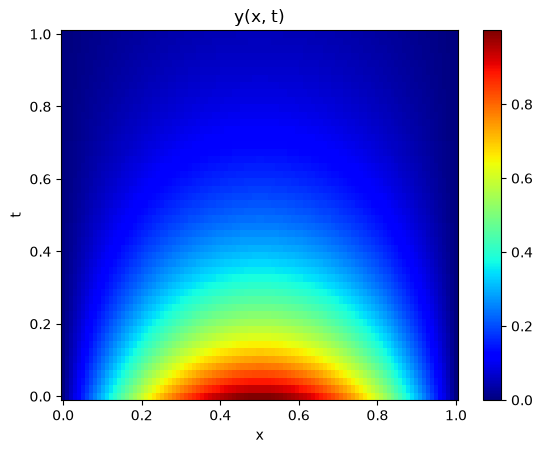

In [2]:
class Dataset:

    def __init__(self, alpha=0.3,
                 xmin=0, tmin=0,
                 xmax=1, tmax=1,
                 Nx=100, Nt=50,
                 m=1, n=3):
        self.m, self.n = m, n
        self.alpha = alpha
        self.tmin, self.xmin = tmin, xmin
        self.tmax, self.xmax = tmax, xmax

        self.x = np.linspace(xmin, xmax, Nx)
        self.t = np.linspace(tmin, tmax, Nt)
        self.x, self.t = np.meshgrid(self.x, self.t)
        self.calculate_solution()

    def calculate_solution(self):
        m, n, alpha = self.m, self.n, self.alpha
        self.solution = np.exp(-n**2 * np.pi**2 * alpha * self.t / m**2) * \
            np.sin(n * np.pi * self.x / m)


# создать датасет с m=1, n=1, alpha=0.3
data = Dataset(alpha=0.3, m=1, n=1)

# нарисовать график с аналитическим решением
plt.pcolormesh(data.x, data.t, data.solution, shading="auto", cmap="jet")
plt.colorbar()
plt.xlabel("x")
plt.ylabel("t")
plt.title("y(x, t)")
plt.show()

## Модель PINN

In [3]:
class SomeModel(nn.Module):
    def __init__(self,
                input_size=2,     # (x, t)
                nnodes=30,        # кол-во нейронов на скрытом слое
                output_size=1,    # кол-во выходных данных
                nlayers=6,        # кол-во скрытых слоев
                activation=nn.Tanh(),
                 ):
        super().__init__()
        self.activation = activation
        self.nlayers = nlayers
        self.nnodes = nnodes

        self.dense0 = nn.Linear(input_size, nnodes)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(nnodes, nnodes) for _ in range(nlayers - 1)
        ])

        self.output_layer = nn.Linear(nnodes, output_size)
        self.apply(self._init_weights_xavier)

    def _init_weights_xavier(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x, t):
        if x.dtype == torch.float64:
            x = x.float()
        if t.dtype == torch.float64:
            t = t.float()
        inp = torch.cat([x, t], dim=1)
        out = self.activation(self.dense0(inp))
        for layer in self.hidden_layers:
            out = self.activation(layer(out))
        out = self.output_layer(out)
        return out

## Батчи: внутренние точки и граничные/начальные условия

In [4]:
class Batch_bc:
    """Точки с известными значениями u -- для ГУ и НУ."""

    def __init__(self, x, t, values):
        self.x_all = torch.tensor(np.asarray(x), dtype=torch.float32).reshape(-1, 1)
        self.t_all = torch.tensor(np.asarray(t), dtype=torch.float32).reshape(-1, 1)
        self.u_all = torch.tensor(np.asarray(values), dtype=torch.float32).reshape(-1, 1)

    def generate_points(self, N):
        n_total = self.x_all.shape[0]
        indices = torch.randperm(n_total)[:N]
        self.points = torch.cat([self.x_all[indices], self.t_all[indices]], dim=1).to(device)
        self.values = self.u_all[indices].to(device)
        self.points.requires_grad = True
        return self.points, self.values


class Batch:
    """Внутренние точки коллокации для невязки PDE."""

    def __init__(self, data: Dataset):
        self.grid = np.stack([data.x.reshape(-1), data.t.reshape(-1)], axis=1)
        self.u = data.solution.reshape(-1, 1)

    def generate_points(self, N):
        n_total = self.grid.shape[0]
        indices = torch.randperm(n_total)[:N]
        self.points = torch.tensor(self.grid[indices], dtype=torch.float32, device=device)
        self.values = torch.tensor(self.u[indices], dtype=torch.float32, device=device)
        self.points.requires_grad = True
        return self.points, self.values

## Невязка PDE и функции потерь

In [5]:
def PDE(u, grid, alpha):
    gradu = torch.autograd.grad(u, grid, grad_outputs=torch.ones_like(u),
                                 create_graph=True)[0]
    u_x = gradu[:, 0:1]
    u_t = gradu[:, 1:2]

    u_xx = torch.autograd.grad(u_x, grid, grad_outputs=torch.ones_like(u_x),
                                create_graph=True)[0][:, 0:1]

    residuals = torch.mean((u_t - alpha * u_xx)**2)
    return residuals


def copyBCLoss(model, grid, sol):
    out = model(grid[:, 0:1], grid[:, 1:2])
    loss = torch.mean((out - sol)**2)
    return loss

In [6]:
class TrainParams:
    def __init__(self):
        self.alpha = None       # параметр в уравнении диффузии
        self.numEpoch = None    # кол-во эпох в цикле обучения
        self.numPoints = None   # размер батча для обучения во внутренней области
        self.batch = None       # сам батч, class Batch
        self.init_bc = None     # батч для НУ, class Batch_bc
        self.right_bc = None    # батч для ГУ справа, class Batch_bc
        self.left_bc = None     # батч для ГУ слева, class Batch_bc
        self.numBCPoints = None # кол-во точек в батче для ГУ/НУ


def residuals(model, trp: TrainParams):
    grid, _ = trp.batch.generate_points(trp.numPoints)
    out = model(grid[:, 0:1], grid[:, 1:2])
    lossPDE = PDE(out, grid, trp.alpha)

    init_grid, init_sol = trp.init_bc.generate_points(trp.numBCPoints)
    initBCLoss = copyBCLoss(model, init_grid, init_sol)

    right_grid, right_sol = trp.right_bc.generate_points(trp.numBCPoints)
    rightBCLoss = copyBCLoss(model, right_grid, right_sol)

    left_grid, left_sol = trp.left_bc.generate_points(trp.numBCPoints)
    leftBCLoss = copyBCLoss(model, left_grid, left_sol)

    k_bc = 10.0
    loss = lossPDE + k_bc * (initBCLoss + rightBCLoss + leftBCLoss)
    return loss

## Цикл обучения

In [7]:
def train(model, opt, scheduler, trPs: TrainParams):
    pbar = tqdm.tqdm(range(trPs.numEpoch), desc="Training Progress")
    for step in pbar:

        def closure():
            opt.zero_grad()
            loss = residuals(model, trPs)
            loss.backward()
            return loss

        current_loss = opt.step(closure)
        lrs.append(opt.param_groups[0]["lr"])
        scheduler.step()

        hist_loss.append(float(current_loss))

        if step % 2 == 0:
            pbar.set_description("Step: %d | Loss: %.10f" %
                                 (step, float(current_loss)))

    return 0

## Подготовка батчей и визуализация точек обучения

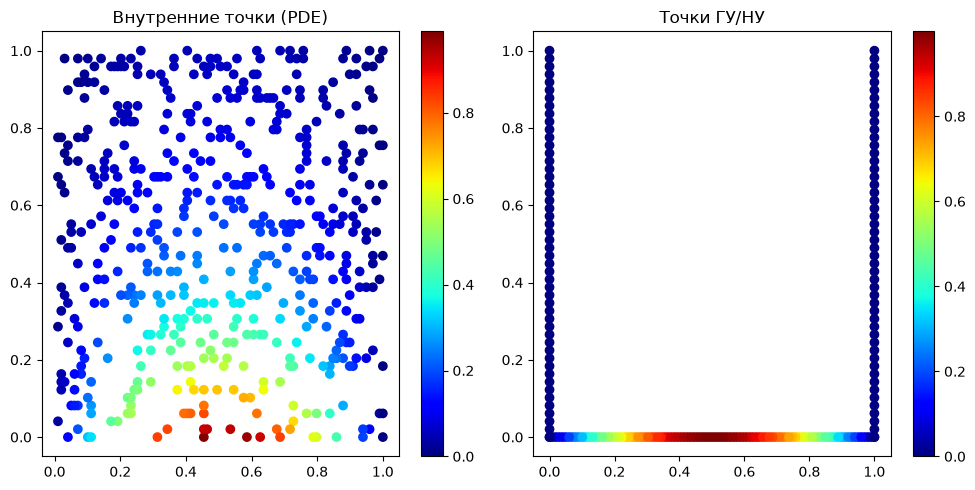

In [8]:
def make_bc_batches(dataset: Dataset):
    x_line = dataset.x[0, :]
    t_line = dataset.t[:, 0]

    init_bc = Batch_bc(x_line, np.zeros_like(x_line),
                        np.sin(dataset.n * np.pi * x_line / dataset.m))
    left_bc = Batch_bc(np.zeros_like(t_line), t_line, np.zeros_like(t_line))
    right_bc = Batch_bc(np.full_like(t_line, dataset.m), t_line, np.zeros_like(t_line))
    return init_bc, left_bc, right_bc


# передайте нужные параметры
train_batch = Batch(data)
initial_bc, left_bc, right_bc = make_bc_batches(data)

# сгенерируйте 500 внутренних точек и по 100 точек для ГУ и НУ
train_batch.generate_points(500)
initial_bc.generate_points(100)
left_bc.generate_points(100)
right_bc.generate_points(100)

# постройте график с помощью plt.scatter
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

i = 0
f = ax[i].scatter(train_batch.points[:, 0].detach().cpu(),
                   train_batch.points[:, 1].detach().cpu(),
                   c=train_batch.values.detach().cpu(), cmap="jet")
plt.colorbar(f, ax=ax[i])
ax[i].set_title("Внутренние точки (PDE)")

i = 1
bc_points = torch.cat([initial_bc.points, left_bc.points, right_bc.points], dim=0)
bc_values = torch.cat([initial_bc.values, left_bc.values, right_bc.values], dim=0)
f = ax[i].scatter(bc_points[:, 0].detach().cpu(),
                   bc_points[:, 1].detach().cpu(),
                   c=bc_values.detach().cpu(), cmap="jet")
plt.colorbar(f, ax=ax[i])
ax[i].set_title("Точки ГУ/НУ")

plt.tight_layout()
plt.show()

## Обучение модели

In [9]:
trPs = TrainParams()
trPs.alpha = data.alpha

trPs.batch = train_batch
trPs.init_bc = initial_bc
trPs.right_bc = right_bc
trPs.left_bc = left_bc

trPs.numPoints = 500
trPs.numBCPoints = 100
trPs.numEpoch = 2000

model = SomeModel().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-2)

lambda1 = lambda epoch: 0.5 ** (epoch // 300)
scheduler = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lambda1)

lrs = []
hist_loss = []

train(model, opt, scheduler, trPs)

Training Progress:   0%|          | 0/2000 [00:00<?, ?it/s]

/var/folders/qk/y97w35cn1ygbpwckyw5hv_j80000gn/T/ipykernel_20231/3208270875.py:15: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:821.)
  hist_loss.append(float(current_loss))
Step: 0 | Loss: 3.9157545567:   0%|          | 0/2000 [00:00<?, ?it/s]

Step: 0 | Loss: 3.9157545567:   0%|          | 1/2000 [00:00<12:12,  2.73it/s]

Step: 2 | Loss: 5.9073176384:   0%|          | 1/2000 [00:00<12:12,  2.73it/s]

Step: 4 | Loss: 7.9193372726:   0%|          | 1/2000 [00:00<12:12,  2.73it/s]

...

Step: 1994 | Loss: 0.0019288275: 100%|█████████▉| 1993/2000 [00:29<00:00, 70.18it/s]

Step: 1996 | Loss: 0.0017875341: 100%|█████████▉| 1993/2000 [00:29<00:00, 70.18it/s]

Step: 1998 | Loss: 0.0015814377: 100%|█████████▉| 1993/2000 [00:29<00:00, 70.18it/s]

Step: 1998 | Loss: 0.0015814377: 100%|██████████| 2000/2000 [00:29<00:00, 68.61it/s]

0

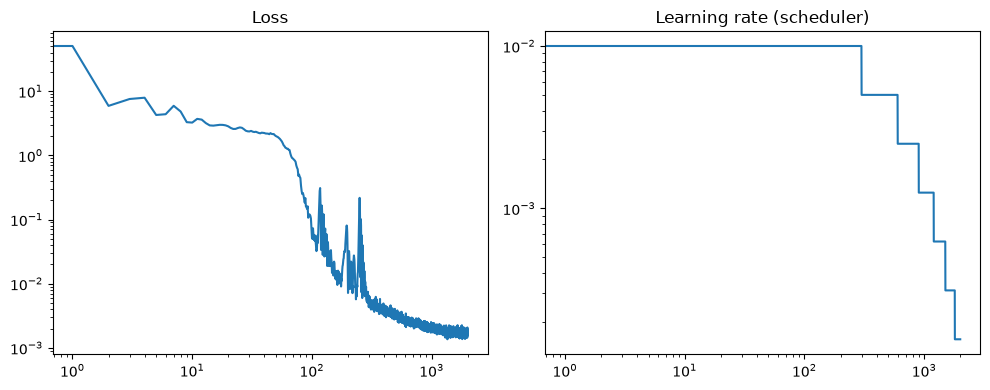

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

i = 0
ax[i].plot(hist_loss)
ax[i].set_xscale("log")
ax[i].set_yscale("log")
ax[i].set_title("Loss")

i = 1
ax[i].plot(lrs)
ax[i].set_xscale("log")
ax[i].set_yscale("log")
ax[i].set_title("Learning rate (scheduler)")

plt.tight_layout()
plt.show()

## Сравнение предсказания с аналитическим решением

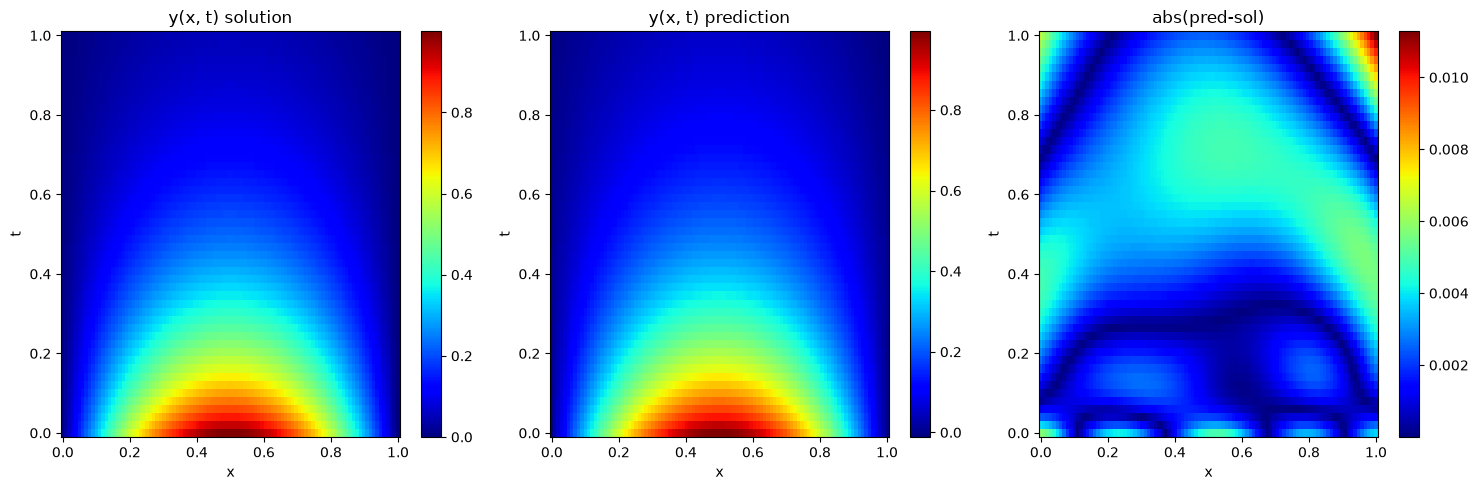

RMSE = 0.00301, относительная СКЗ ошибка = 1.02%


In [11]:
x_flat = torch.tensor(data.x.reshape(-1, 1), dtype=torch.float32, device=device)
t_flat = torch.tensor(data.t.reshape(-1, 1), dtype=torch.float32, device=device)

grid_pred = torch.cat([x_flat, t_flat], dim=1)
pred = model(grid_pred[:, 0:1], grid_pred[:, 1:2]).detach().cpu().numpy().reshape(data.x.shape)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

i = 0
f = ax[i].pcolor(data.x, data.t, data.solution, shading="auto", cmap="jet")
plt.colorbar(f, ax=ax[i])
ax[i].set_xlabel("x"); ax[i].set_ylabel("t"); ax[i].set_title("y(x, t) solution")

i = 1
f = ax[i].pcolor(data.x, data.t, pred, shading="auto", cmap="jet")
plt.colorbar(f, ax=ax[i])
ax[i].set_xlabel("x"); ax[i].set_ylabel("t"); ax[i].set_title("y(x, t) prediction")

i = 2
f = ax[i].pcolor(data.x, data.t, np.abs(pred - data.solution), shading="auto", cmap="jet")
plt.colorbar(f, ax=ax[i])
ax[i].set_xlabel("x"); ax[i].set_ylabel("t"); ax[i].set_title("abs(pred-sol)")

plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean((pred - data.solution)**2))
rel_error = rmse / np.sqrt(np.mean(data.solution**2)) * 100
print(f"RMSE = {rmse:.5f}, относительная СКЗ ошибка = {rel_error:.2f}%")